# Example of how to load basis set coefficients from Basis Set Exchange

In [18]:
import basis_set_exchange as bse
import torch

element = "O"
basis_name = "STO-3G"

Z = 8

# Load basis and locate element entry
basis = bse.get_basis(basis_name, elements=[element])
shells = basis["elements"][str(Z)]["electron_shells"]

# Filter all s-type shells (angular momentum [0])
s_shells = [sh for sh in shells if sh["angular_momentum"] == [0]]
if not s_shells:
    raise ValueError(f"No s-type shells found for {element} in {basis_name}")

# Choose the more diffuse s-shell (the one with smaller exponent → 2s)
def smallest_exp(shell):
    return min(float(x) for x in shell["exponents"])
shell_2s = sorted(s_shells, key=smallest_exp)[0]  # pick shell with smallest exponent → valence 2s

# Extract exponents and coefficients
alpha = torch.tensor([float(a) for a in shell_2s["exponents"]], dtype=torch.float64)
c = torch.tensor([float(cn) for cn in shell_2s["coefficients"][0]], dtype=torch.float64)

print(f"{element} 2s exponents (alpha):", alpha)
print(f"{element} 2s contraction coefficients (c):", c)



O 2s exponents (alpha): tensor([130.7093,  23.8089,   6.4436])
O 2s contraction coefficients (c): tensor([0.1543, 0.5353, 0.4446])


# Define Carbon and Hydrogen Orbitals
+ Evaluate Inter-Atomic Potentials: T, V, J, K

R= 0.600 bohr: T=1.388499, V=-4.465589, J=0.722964, K=0.630538, ENN=1.666667, E_total=-0.660864
R= 0.752 bohr: T=1.340105, V=-4.293182, J=0.697391, K=0.565600, ENN=1.330275, E_total=-0.885563
R= 0.903 bohr: T=1.296781, V=-4.126249, J=0.669095, K=0.498322, ENN=1.106870, E_total=-0.999000
R= 1.055 bohr: T=1.260254, V=-3.970348, J=0.639169, K=0.432129, ENN=0.947712, E_total=-1.053296
R= 1.207 bohr: T=1.230452, V=-3.827713, J=0.608535, K=0.369426, ENN=0.828571, E_total=-1.074637
R= 1.359 bohr: T=1.206629, V=-3.698951, J=0.577936, K=0.311755, ENN=0.736041, E_total=-1.077507
R= 1.510 bohr: T=1.188168, V=-3.583929, J=0.547943, K=0.259991, ENN=0.662100, E_total=-1.070186
R= 1.662 bohr: T=1.174838, V=-3.482124, J=0.518976, K=0.214497, ENN=0.601660, E_total=-1.057269
R= 1.814 bohr: T=1.166663, V=-3.392735, J=0.491325, K=0.175249, ENN=0.551331, E_total=-1.041141
R= 1.966 bohr: T=1.163658, V=-3.314766, J=0.465173, K=0.141944, ENN=0.508772, E_total=-1.022969
R= 2.117 bohr: T=1.165640, V=-3.247098, 

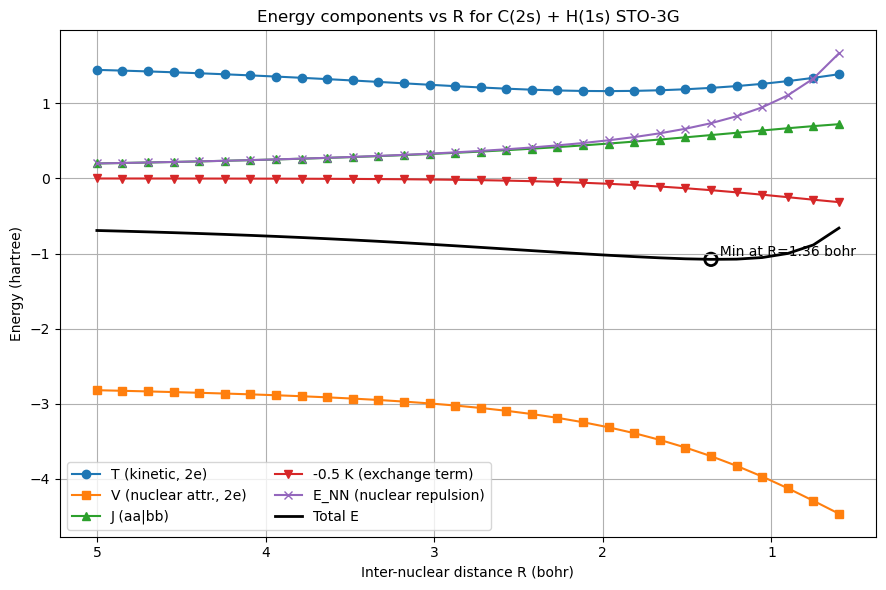

In [14]:
import torch
import math
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

# --- STO-3G primitives & contractions ---
# Carbon 2s (STO-3G)
alpha_C2s = torch.tensor([3.42525091, 0.62391373, 0.16885540], dtype=torch.float64)
c_C2s     = torch.tensor([0.15432897, 0.53532814, 0.44463454], dtype=torch.float64)

# Hydrogen 1s (STO-3G)
alpha_H1s = torch.tensor([3.42525091, 0.62391373, 0.16885540], dtype=torch.float64)
c_H1s     = torch.tensor([0.15432897, 0.53532814, 0.44463454], dtype=torch.float64)

# primitive normalization for s Gaussian: N = (2a/pi)^(3/4)
def prim_norm(a):
    # a can be scalar tensor
    return (2.0 * a / math.pi) ** (3.0 / 4.0)

# Boys F0 with small-t handling
def boys_F0(t):
    t = torch.as_tensor(t, dtype=torch.float64)
    out = torch.empty_like(t)
    small = t <= 1e-12
    if small.any():
        out[small] = 1.0
    if (~small).any():
        ts = t[~small]
        out[~small] = 0.5 * math.sqrt(math.pi) * torch.erf(torch.sqrt(ts)) / torch.sqrt(ts)
    return out

# primitive overlap
def prim_overlap(a, b, RA, RB):
    p = a + b
    mu = a * b / p
    Rab2 = torch.sum((RA - RB) ** 2, dim=-1)
    return (math.pi / p) ** 1.5 * torch.exp(-mu * Rab2)

# primitive kinetic
def prim_kinetic(a, b, RA, RB):
    p = a + b
    mu = a * b / p
    Rab2 = torch.sum((RA - RB) ** 2, dim=-1)
    pref = (math.pi / p) ** 1.5 * torch.exp(-mu * Rab2)
    return pref * mu * (3.0 - 2.0 * mu * Rab2)

# primitive nuclear attraction to nucleus at RC with charge Zc
def prim_nuclear_attraction(a, b, RA, RB, RC, Zc=1.0):
    p = a + b
    mu = a * b / p
    Rab2 = torch.sum((RA - RB) ** 2, dim=-1)
    P = (a * RA + b * RB) / p
    PC2 = torch.sum((P - RC) ** 2, dim=-1)
    pref = -Zc * 2.0 * math.pi / p * torch.exp(-mu * Rab2)
    return pref * boys_F0(p * PC2)

# primitive electron repulsion integral (ab|cd) for s primitives
def prim_eri(a, b, c, d, RA, RB, RC, RD):
    p = a + b
    q = c + d
    mu = a * b / p
    nu = c * d / q
    Rab2 = torch.sum((RA - RB) ** 2, dim=-1)
    Rcd2 = torch.sum((RC - RD) ** 2, dim=-1)
    P = (a * RA + b * RB) / p
    Q = (c * RC + d * RD) / q
    PQ2 = torch.sum((P - Q) ** 2, dim=-1)
    pref = 2.0 * (math.pi ** 2.5) / (p * q * torch.sqrt(p + q))
    t = (p * q / (p + q)) * PQ2
    return pref * torch.exp(-mu * Rab2 - nu * Rcd2) * boys_F0(t)

# Vectorized contracted two-center integrals (op_prim must broadcast over a,b)
def contracted_two_center_vec(alphaA, cA, RA, alphaB, cB, RB, op_prim):
    a = alphaA.view(-1,1)   # (nA,1)
    b = alphaB.view(1,-1)   # (1,nB)
    prim_vals = op_prim(a, b, RA, RB)    # expect shape (nA,nB)
    Na = torch.tensor([prim_norm(ai) for ai in alphaA], dtype=torch.float64).view(-1,1)
    Nb = torch.tensor([prim_norm(bi) for bi in alphaB], dtype=torch.float64).view(1,-1)
    coeffs = (cA.view(-1,1) * Na) * (cB.view(1,-1) * Nb)
    return (coeffs * prim_vals).sum()

# Contracted ERI (small loops are fine for 3x3 primitives)
def contracted_eri(alphaA, cA, RA, alphaB, cB, RB, alphaC, cC, RC, alphaD, cD, RD):
    total = 0.0
    for i in range(alphaA.numel()):
        ai = alphaA[i]; Ni = prim_norm(ai)
        for j in range(alphaB.numel()):
            bj = alphaB[j]; Nj = prim_norm(bj)
            for k in range(alphaC.numel()):
                ck = alphaC[k]; Nk = prim_norm(ck)
                for l in range(alphaD.numel()):
                    dl = alphaD[l]; Nl = prim_norm(dl)
                    val_prim = prim_eri(ai, bj, ck, dl, RA, RB, RC, RD)
                    total += (cA[i]*Ni) * (cB[j]*Nj) * (cC[k]*Nk) * (cD[l]*Nl) * val_prim
    return total

# ---------------------------
# Loop over R (in bohr) and compute components
# ---------------------------
Z_C = 1.0
Z_H = 1.0

# Choose R range in bohr (example)
R_values = np.linspace(0.6, 5.0, 30)   # bohr

T_list = []
V_list = []
J_list = []
K_list = []
ENN_list = []
Etotal_list = []

for R in R_values:
    RA = torch.tensor([-R/2.0, 0.0, 0.0], dtype=torch.float64)   # Carbon center (bohr)
    RB = torch.tensor([ R/2.0, 0.0, 0.0], dtype=torch.float64)   # Hydrogen center (bohr)

    # Overlaps
    S_AA = contracted_two_center_vec(alpha_C2s, c_C2s, RA, alpha_C2s, c_C2s, RA, prim_overlap)
    S_BB = contracted_two_center_vec(alpha_H1s, c_H1s, RB, alpha_H1s, c_H1s, RB, prim_overlap)
    S_AB = contracted_two_center_vec(alpha_C2s, c_C2s, RA, alpha_H1s, c_H1s, RB, prim_overlap)

    # Kinetic integrals
    T_AA = contracted_two_center_vec(alpha_C2s, c_C2s, RA, alpha_C2s, c_C2s, RA, prim_kinetic)
    T_BB = contracted_two_center_vec(alpha_H1s, c_H1s, RB, alpha_H1s, c_H1s, RB, prim_kinetic)
    T_AB = contracted_two_center_vec(alpha_C2s, c_C2s, RA, alpha_H1s, c_H1s, RB, prim_kinetic)

    # Nuclear attraction (sum over both nuclei)
    V_AA = contracted_two_center_vec(alpha_C2s, c_C2s, RA, alpha_C2s, c_C2s, RA,
                                     lambda a,b,Ra,Rb: prim_nuclear_attraction(a,b,Ra,Rb, RA, Zc=Z_C) +
                                                     prim_nuclear_attraction(a,b,Ra,Rb, RB, Zc=Z_H))
    V_BB = contracted_two_center_vec(alpha_H1s, c_H1s, RB, alpha_H1s, c_H1s, RB,
                                     lambda a,b,Ra,Rb: prim_nuclear_attraction(a,b,Ra,Rb, RA, Zc=Z_C) +
                                                     prim_nuclear_attraction(a,b,Ra,Rb, RB, Zc=Z_H))
    V_AB = contracted_two_center_vec(alpha_C2s, c_C2s, RA, alpha_H1s, c_H1s, RB,
                                     lambda a,b,Ra,Rb: prim_nuclear_attraction(a,b,Ra,Rb, RA, Zc=Z_C) +
                                                     prim_nuclear_attraction(a,b,Ra,Rb, RB, Zc=Z_H))

    # Build H (one-electron) and S matrices (2x2)
    Tmat = torch.tensor([[T_AA, T_AB],
                         [T_AB, T_BB]], dtype=torch.float64)
    Vmat = torch.tensor([[V_AA, V_AB],
                         [V_AB, V_BB]], dtype=torch.float64)
    Hmat = Tmat + Vmat
    Smat = torch.tensor([[S_AA, S_AB],
                         [S_AB, S_BB]], dtype=torch.float64)

    # symmetric MO: psi = (phi_A + phi_B) / sqrt(2 + 2S_AB)
    denom = math.sqrt(2.0 + 2.0 * float(S_AB))
    ca = 1.0 / denom
    cb = 1.0 / denom
    cvec = torch.tensor([ca, cb], dtype=torch.float64)

    # density P = 2 * c c^T (two electrons in this MO)
    P = 2.0 * torch.outer(cvec, cvec)

    # One-electron energy
    E_one = float((P * Hmat).sum())

    # Two-electron ERIs
    centers = [(alpha_C2s, c_C2s, RA), (alpha_H1s, c_H1s, RB)]
    ERI = torch.zeros((2,2,2,2), dtype=torch.float64)
    for mu in range(2):
        for nu in range(2):
            for lam in range(2):
                for sig in range(2):
                    a_alpha, a_c, a_R = centers[mu]
                    b_alpha, b_c, b_R = centers[nu]
                    c_alpha, c_c, c_R = centers[lam]
                    d_alpha, d_c, d_R = centers[sig]
                    ERI[mu,nu,lam,sig] = contracted_eri(a_alpha, a_c, a_R,
                                                        b_alpha, b_c, b_R,
                                                        c_alpha, c_c, c_R,
                                                        d_alpha, d_c, d_R)

    # Coulomb and Exchange energies
    E_J = 0.5 * float((P.unsqueeze(2).unsqueeze(3) * P.unsqueeze(0).unsqueeze(1) * ERI).sum())
    ERI_ex = ERI.permute(0,2,1,3)  # for (mu lam | nu sig)
    E_K = -0.25 * float((P.unsqueeze(2).unsqueeze(3) * P.unsqueeze(0).unsqueeze(1) * ERI_ex).sum())

    # Total electronic energy (one + two)
    E_elec = E_one + E_J + E_K

    # Breakdown requested: produce components T_total, V_total, J_val, K_val
    T_total = float((P * Tmat).sum())
    V_total = float((P * Vmat).sum())
    # J and K values for (aa|bb) and (ab|ba) to compare with earlier notation:
    J_val = float(ERI[0,0,1,1])
    K_val = float(ERI[0,1,1,0])

    # Nuclear-nuclear repulsion
    ENN = (Z_C * Z_H) / R

    # Total (electronic + nuclear)
    E_total = E_elec + ENN

    # store
    T_list.append(T_total)
    V_list.append(V_total)
    J_list.append(J_val)
    K_list.append(K_val)
    ENN_list.append(ENN)
    Etotal_list.append(E_total)

    print(f"R={R:6.3f} bohr: T={T_total:.6f}, V={V_total:.6f}, J={J_val:.6f}, K={K_val:.6f}, ENN={ENN:.6f}, E_total={E_total:.6f}")

# Convert lists to arrays for plotting
Rs_plot = np.array(R_values)   # bohr
T_plot = np.array(T_list)
V_plot = np.array(V_list)
J_plot = np.array(J_list)
K_plot = np.array(K_list)
ENN_plot = np.array(ENN_list)
E_plot = np.array(Etotal_list)

plt.figure(figsize=(9,6))
plt.plot(Rs_plot, T_plot, label='T (kinetic, 2e)', marker='o')
plt.plot(Rs_plot, V_plot, label='V (nuclear attr., 2e)', marker='s')
plt.plot(Rs_plot, J_plot, label='J (aa|bb)', marker='^')
plt.plot(Rs_plot, -0.5*K_plot, label='-0.5 K (exchange term)', marker='v')
plt.plot(Rs_plot, ENN_plot, label='E_NN (nuclear repulsion)', marker='x')
plt.plot(Rs_plot, E_plot, label='Total E', color='k', linewidth=2)
plt.xlabel('Inter-nuclear distance R (bohr)')
plt.ylabel('Energy (hartree)')
plt.title('Energy components vs R for C(2s) + H(1s) STO-3G')
plt.legend(ncol=2)
plt.grid(True)
plt.gca().invert_xaxis()
min_idx = np.argmin(E_plot)
Rmin = Rs_plot[min_idx]
Emin = E_plot[min_idx]
plt.scatter([Rmin], [Emin], s=80, facecolors='none', edgecolors='k', linewidths=2)
plt.text(Rmin, Emin, f'  Min at R={Rmin:.2f} bohr', verticalalignment='bottom')
plt.tight_layout()
plt.show()


# Train NN to fit Inter-Atomic Potential

Shapes: (30,) (30,)
Epoch    0 | Loss: 2.076051e+00
Epoch  500 | Loss: 3.183335e-01
Epoch 1000 | Loss: 2.280889e-01
Epoch 1500 | Loss: 1.553683e-01
Epoch 2000 | Loss: 1.020525e-01
Epoch 2500 | Loss: 6.265793e-02
Epoch 3000 | Loss: 3.837678e-02
Epoch 3500 | Loss: 2.390724e-02
Epoch 4000 | Loss: 1.509509e-02
Epoch 4500 | Loss: 9.582333e-03


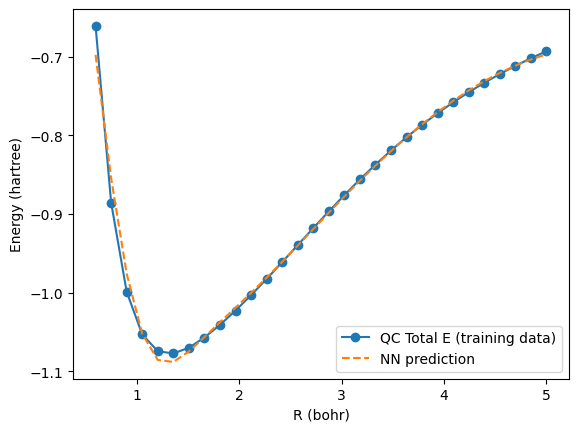

In [16]:
# Use this cell after your QC script cell (so Rs_plot and E_plot exist)
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ensure default dtype is double if you want high precision
torch.set_default_dtype(torch.float64)

# Convert QC outputs to numpy (they already are), then to torch
Rs = np.asarray(Rs_plot)      # (30,) from your QC script
E = np.asarray(E_plot)        # (30,)

print("Shapes:", Rs.shape, E.shape)   # sanity check: should match

# Prepare tensors (N,1)
x = torch.from_numpy(Rs).unsqueeze(1)   # double by default
y = torch.from_numpy(E).unsqueeze(1)

# Simple MLP (double precision)
model_energy = nn.Sequential(
    nn.Linear(1, 32),
    nn.Tanh(),
    nn.Linear(32, 1)
).double()   # ensure parameters are float64

# Loss & optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model_energy.parameters(), lr=1e-3)

# Normalise using training stats (double)
x_mean, x_std = x.mean(), x.std(unbiased=False)
y_mean, y_std = y.mean(), y.std(unbiased=False)
x_norm = (x - x_mean) / (x_std + 1e-12)
y_norm = (y - y_mean) / (y_std + 1e-12)

# Training (full-batch on 30 points)
n_epochs = 5000
for epoch in range(n_epochs):
    model_energy.train()
    y_pred = model_energy(x_norm)
    loss = criterion(y_pred, y_norm)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.6e}")

# Predict and plot
model_energy.eval()
with torch.no_grad():
    y_pred_norm = model_energy(x_norm)
    y_pred = y_pred_norm * (y_std + 1e-12) + y_mean

plt.figure()
plt.plot(Rs, E, 'o-', label='QC Total E (training data)')
plt.plot(Rs, y_pred.squeeze().cpu().numpy(), '--', label='NN prediction')
plt.xlabel('R (bohr)')
plt.ylabel('Energy (hartree)')
plt.legend()
plt.show()